In [12]:
import pandas as pd
df=pd.read_csv('..\sukkiri-ml2-codes\datafiles\Survived.csv')
display(df.head(3))

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df.shape

(891, 11)

In [15]:
df=df.drop(['PassengerId','Ticket','Cabin','Embarked'],axis=1)

In [16]:
df=df.fillna(df['Age'].mean())

In [17]:
#ダミー変数化
dummy=pd.get_dummies(df['Sex'],drop_first=True,dtype=int)
df=df.join(dummy)
df=df.drop(['Sex'],axis=1)

<Axes: >

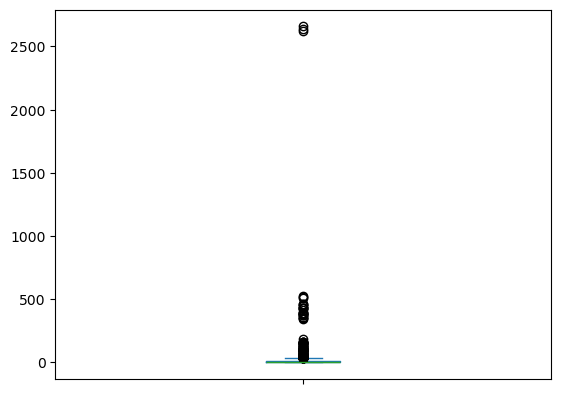

In [18]:
#15-5  #マハラノビス距離を求める
from sklearn.covariance import MinCovDet  #マハラノビス距離
mcd=MinCovDet(random_state=0,support_fraction=0.7)
mcd.fit(df) 
distance=pd.Series(mcd.mahalanobis(df),index=df.index)

#箱ひげ図を描く
distance.plot(kind="box")

<Axes: >

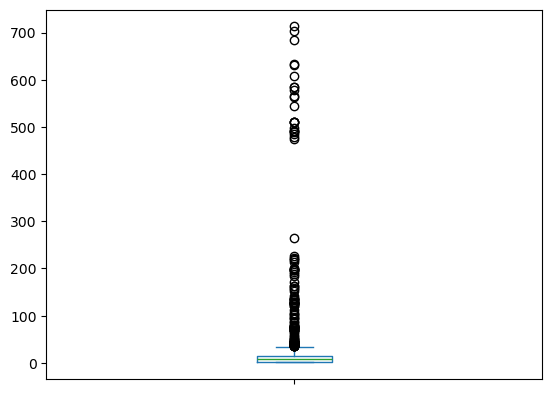

In [19]:
#外れ値の削除(マハラノビス距離が2500以上のもの)
no=distance[distance>2500].index
df=df.drop(no)

mcd.fit(df) 
dis2=mcd.mahalanobis(df)
dis2=pd.Series(dis2)
dis2.plot(kind="box")

In [20]:
df.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,male
0,0,3,22.0,1,0,7.2500,1
1,1,1,38.0,1,0,71.2833,0
2,1,3,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,0,3,35.0,0,0,8.0500,1


In [21]:
#標準化
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc_df=sc.fit_transform(df)
sc_df=pd.DataFrame(sc_df)
sc_df.columns=df.columns

In [22]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=2,random_state=0)
model.fit(sc_df)
sc_df['cluster']=model.labels_

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [23]:
sc_df.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,male,cluster
0,-0.785803,0.824123,-0.590209,0.430627,-0.473353,-0.566959,0.737799,0
1,1.272584,-1.575290,0.639380,0.430627,-0.473353,0.989016,-1.355382,1
2,1.272584,0.824123,-0.282812,-0.475527,-0.473353,-0.550557,-1.355382,1
3,1.272584,-1.575290,0.408832,0.430627,-0.473353,0.547171,-1.355382,1
4,-0.785803,0.824123,0.408832,-0.475527,-0.473353,-0.547519,0.737799,0


<Axes: xlabel='cluster'>

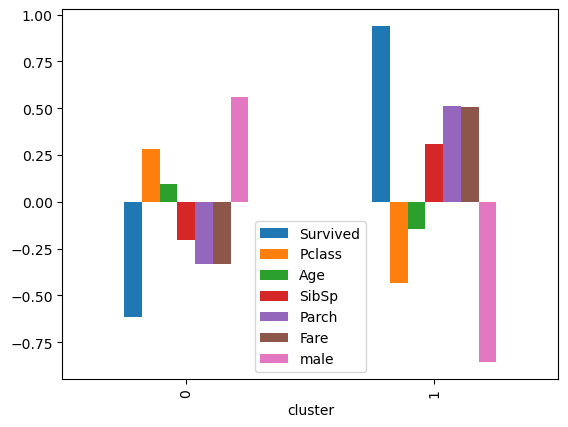

In [24]:
cluster_mean=sc_df.groupby('cluster').mean()
cluster_mean.plot(kind='bar')

In [ ]:
'''
0　非生存者
１　生存者
'''